In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)

In [4]:
# câu 1: Tải dữ liệu từ 1 file duy nhất
def load_data():
    df = pd.read_csv('titanic_disaster.csv')
    return df

# Hoặc nếu cần upload lên Colab:
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(list(uploaded.keys())[0])

df = load_data()
print("Kích thước dữ liệu:", df.shape)
print("\n10 dòng đầu tiên:")
print(df.head(10))

Kích thước dữ liệu: (891, 12)

10 dòng đầu tiên:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6              

In [8]:
# PHẦN 1b: Chia thành train và test (80% train, 20% test)
# Giữ lại PassengerId để sau này dễ theo dõi
train_df, test_df = train_test_split(
    df,
    test_size=0.2,          # 20% cho test
    random_state=42,        # cố định kết quả chia
    stratify=df.get('Survived', None)  # nếu có cột Survived thì chia đều tỷ lệ
)

print(f"Tập train: {train_df.shape}")
print(f"Tập test: {test_df.shape}")
print(f"\nTỷ lệ Survived trên train:")
if 'Survived' in train_df.columns:
    print(train_df['Survived'].value_counts(normalize=True))

Tập train: (712, 12)
Tập test: (179, 12)

Tỷ lệ Survived trên train:
Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64


Thống kê dữ liệu thiếu trên tập train:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            137
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          552
Embarked         2
dtype: int64


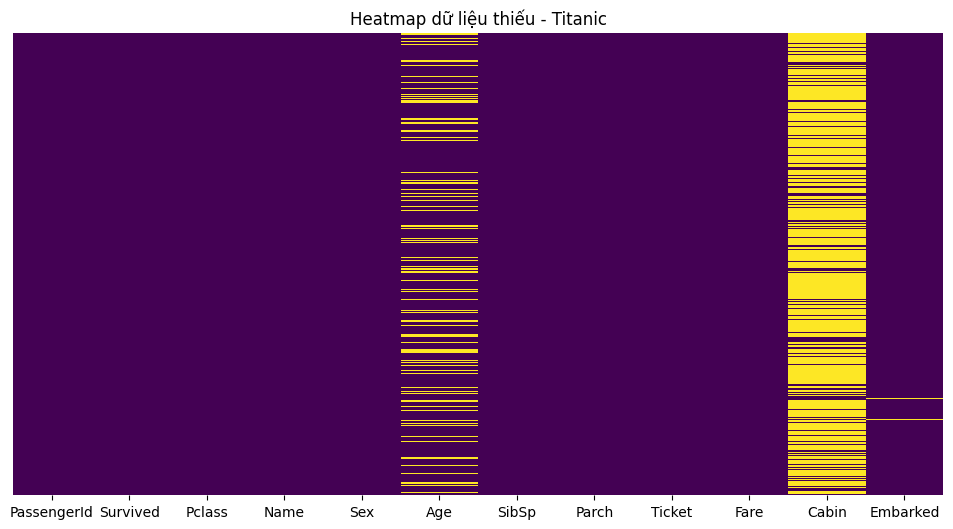


=== NHẬN XÉT ===
Age: thiếu 137 giá trị
Cabin: thiếu 552 giá trị (rất nhiều)
Embarked: thiếu 2 giá trị


In [7]:
#câu 2
# Thống kê số lượng dữ liệu thiếu
print("Thống kê dữ liệu thiếu trên tập train:")
print(train_df.isnull().sum())

# Vẽ heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(train_df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Heatmap dữ liệu thiếu - Titanic')
plt.show()

# Nhận xét
print("\n=== NHẬN XÉT ===")
print("Age: thiếu", train_df['Age'].isnull().sum(), "giá trị")
print("Cabin: thiếu", train_df['Cabin'].isnull().sum(), "giá trị (rất nhiều)")
print("Embarked: thiếu", train_df['Embarked'].isnull().sum(), "giá trị")

In [9]:
#câu3
# Xem thử cột Name hiện tại
print("Cột Name hiện tại:")
print(train_df['Name'].head())

# Tách tên
def split_name(df):
    # Tách theo dấu phẩy
    name_parts = df['Name'].str.split(',', expand=True)
    df['secondName'] = name_parts[0].str.strip()  # Họ
    df['firstName'] = name_parts[1].str.strip() if name_parts.shape[1] > 1 else ''  # Tên + danh xưng
    df.drop('Name', axis=1, inplace=True)
    return df

train_df = split_name(train_df)
test_df = split_name(test_df)

# Kiểm tra kết quả
print("\nSau khi tách:")
print(train_df[['firstName', 'secondName']].head(10))

Cột Name hiện tại:
692                                   Lam, Mr. Ali
481               Frost, Mr. Anthony Wood "Archie"
527                             Farthing, Mr. John
855                     Aks, Mrs. Sam (Leah Rosen)
801    Collyer, Mrs. Harvey (Charlotte Annie Tate)
Name: Name, dtype: object

Sau khi tách:
                                    firstName     secondName
692                                   Mr. Ali            Lam
481                 Mr. Anthony Wood "Archie"          Frost
527                                  Mr. John       Farthing
855                     Mrs. Sam (Leah Rosen)            Aks
801        Mrs. Harvey (Charlotte Annie Tate)        Collyer
652                    Mr. Johannes Halvorsen         Kalvik
509                                  Mr. Fang           Lang
557                                Mr. Victor        Robbins
828                         Mr. Thomas Joseph      McCormack
18   Mrs. Julius (Emelia Maria Vandemoortele)  Vander Planke


In [10]:
#câu4
# Xem giá trị hiện tại
print("Giá trị hiện tại của cột Sex:")
print(train_df['Sex'].value_counts())

# Thay thế
train_df['Sex'] = train_df['Sex'].map({'male': 'M', 'female': 'F'})
test_df['Sex'] = test_df['Sex'].map({'male': 'M', 'female': 'F'})

# Kiểm tra
print("\nSau khi thay thế:")
print(train_df['Sex'].value_counts())
print("\n10 dòng đầu cột Sex:")
print(train_df['Sex'].head(10))

Giá trị hiện tại của cột Sex:
Sex
male      459
female    253
Name: count, dtype: int64

Sau khi thay thế:
Sex
M    459
F    253
Name: count, dtype: int64

10 dòng đầu cột Sex:
692    M
481    M
527    M
855    F
801    F
652    M
509    M
557    M
828    M
18     F
Name: Sex, dtype: object


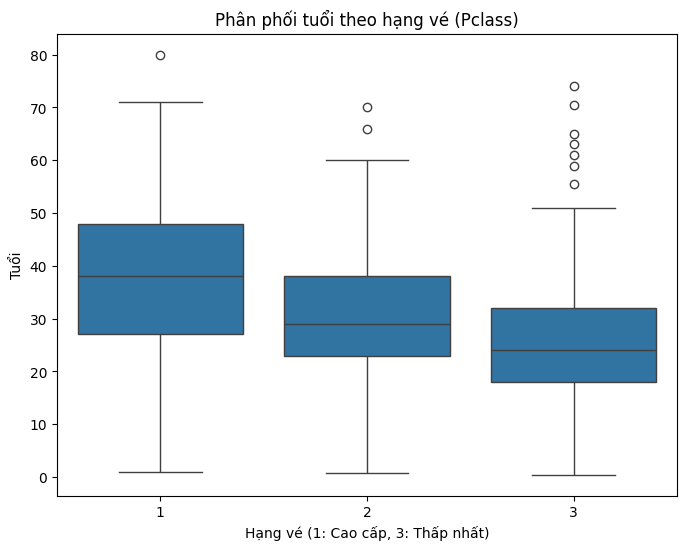

Tuổi trung bình theo từng hạng vé:
Pclass
1    38.037379
2    30.119362
3    25.526540
Name: Age, dtype: float64

Nhận xét: Hạng 1 có tuổi trung bình cao nhất, hạng 3 thấp nhất
=> Nên thay thế Age thiếu bằng trung bình theo từng Pclass


In [11]:
#câu 5 a
# Vẽ boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Pclass', y='Age', data=train_df)
plt.title('Phân phối tuổi theo hạng vé (Pclass)')
plt.xlabel('Hạng vé (1: Cao cấp, 3: Thấp nhất)')
plt.ylabel('Tuổi')
plt.show()

# Tính tuổi trung bình theo từng hạng
print("Tuổi trung bình theo từng hạng vé:")
print(train_df.groupby('Pclass')['Age'].mean())
print("\nNhận xét: Hạng 1 có tuổi trung bình cao nhất, hạng 3 thấp nhất")
print("=> Nên thay thế Age thiếu bằng trung bình theo từng Pclass")

Số lượng Age bị thiếu TRƯỚC khi xử lý:
Train: 137
Test: 40

Số lượng Age bị thiếu SAU khi xử lý:
Train: 0
Test: 0


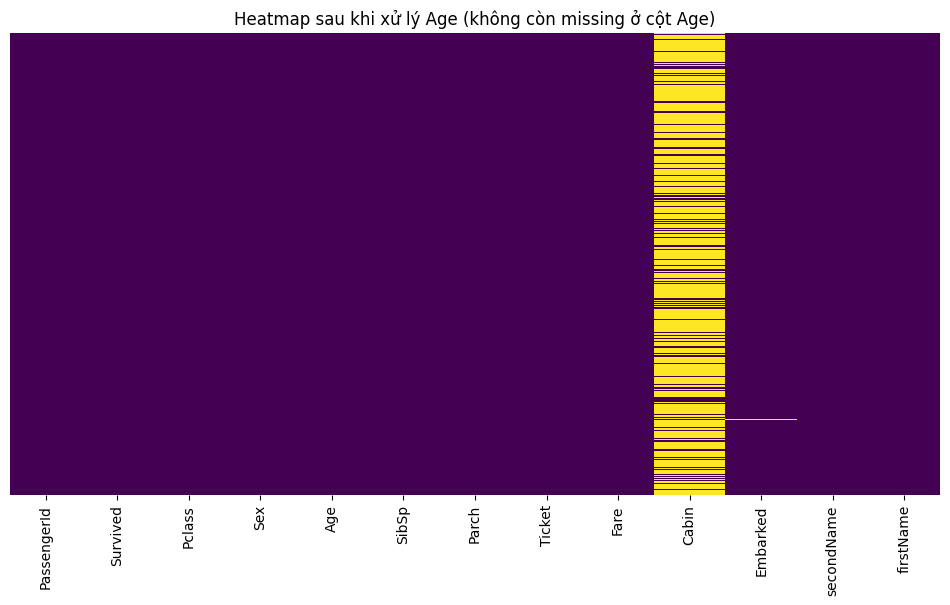

In [12]:
#câu 5b
# Kiểm tra số lượng missing trước khi xử lý
print("Số lượng Age bị thiếu TRƯỚC khi xử lý:")
print("Train:", train_df['Age'].isnull().sum())
print("Test:", test_df['Age'].isnull().sum())

# Hàm thay thế
def fill_age_by_pclass(df):
    df['Age'] = df.groupby('Pclass')['Age'].transform(
        lambda x: x.fillna(x.mean())
    )
    return df

train_df = fill_age_by_pclass(train_df)
test_df = fill_age_by_pclass(test_df)

# Kiểm tra sau khi xử lý
print("\nSố lượng Age bị thiếu SAU khi xử lý:")
print("Train:", train_df['Age'].isnull().sum())
print("Test:", test_df['Age'].isnull().sum())

# Vẽ lại heatmap để xác nhận
plt.figure(figsize=(12, 6))
sns.heatmap(train_df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Heatmap sau khi xử lý Age (không còn missing ở cột Age)')
plt.show()

In [13]:
#câu6
# Tạo biến Agegroup
def create_agegroup(df):
    bins = [0, 12, 18, 60, 120]  # Các mốc tuổi
    labels = ['Kid', 'Teen', 'Adult', 'Older']
    df['Agegroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)
    return df

train_df = create_agegroup(train_df)
test_df = create_agegroup(test_df)

# Kiểm tra kết quả
print("Phân bố Agegroup trên tập train:")
print(train_df['Agegroup'].value_counts())

# Xem thử 10 dòng
print("\n10 dòng đầu tiên (Age và Agegroup):")
print(train_df[['Age', 'Agegroup']].head(10))

Phân bố Agegroup trên tập train:
Agegroup
Adult    588
Kid       55
Teen      53
Older     16
Name: count, dtype: int64

10 dòng đầu tiên (Age và Agegroup):
           Age Agegroup
692  25.526540    Adult
481  30.119362    Adult
527  38.037379    Adult
855  18.000000     Teen
801  31.000000    Adult
652  21.000000    Adult
509  26.000000    Adult
557  38.037379    Adult
828  25.526540    Adult
18   31.000000    Adult


In [14]:
#câu7
# Xem thử cột secondName
print("Cột secondName hiện tại:")
print(train_df['secondName'].head(10))

# Tách danh xưng (lấy từ trước dấu chấm)
def extract_prefix(df):
    # pattern: tìm chữ cái đứng trước dấu chấm (Mr., Mrs., Miss., Master., v.v)
    df['namePrefix'] = df['secondName'].str.extract(r'([A-Za-z]+)\.', expand=False)
    return df

train_df = extract_prefix(train_df)
test_df = extract_prefix(test_df)

# Kiểm tra
print("\nCác danh xưng xuất hiện:")
print(train_df['namePrefix'].value_counts())

print("\n10 dòng đầu (secondName và namePrefix):")
print(train_df[['secondName', 'namePrefix']].head(10))

Cột secondName hiện tại:
692              Lam
481            Frost
527         Farthing
855              Aks
801          Collyer
652           Kalvik
509             Lang
557          Robbins
828        McCormack
18     Vander Planke
Name: secondName, dtype: object

Các danh xưng xuất hiện:
Series([], Name: count, dtype: int64)

10 dòng đầu (secondName và namePrefix):
        secondName namePrefix
692            Lam        NaN
481          Frost        NaN
527       Farthing        NaN
855            Aks        NaN
801        Collyer        NaN
652         Kalvik        NaN
509           Lang        NaN
557        Robbins        NaN
828      McCormack        NaN
18   Vander Planke        NaN


In [16]:
#câu8
# Tạo familySize = 1 + SibSp + Parch
train_df['familySize'] = 1 + train_df['SibSp'] + train_df['Parch']
test_df['familySize'] = 1 + test_df['SibSp'] + test_df['Parch']

# Thống kê
print("Thống kê familySize trên tập train:")
print(train_df['familySize'].describe())

# Phân bố
print("\nPhân bố familySize:")
print(train_df['familySize'].value_counts().sort_index())

# Xem thử
print("\n10 dòng đầu (SibSp, Parch, familySize):")
print(train_df[['SibSp', 'Parch', 'familySize']].head(10))

Thống kê familySize trên tập train:
count    712.000000
mean       1.883427
std        1.589047
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       11.000000
Name: familySize, dtype: float64

Phân bố familySize:
familySize
1     434
2     129
3      77
4      22
5      14
6      16
7      11
8       4
11      5
Name: count, dtype: int64

10 dòng đầu (SibSp, Parch, familySize):
     SibSp  Parch  familySize
692      0      0           1
481      0      0           1
527      0      0           1
855      0      1           2
801      1      1           3
652      0      0           1
509      0      0           1
557      0      0           1
828      0      0           1
18       1      0           2


In [17]:
#câu9
# Alone = 1 nếu familySize == 1 (đi một mình), ngược lại = 0
train_df['Alone'] = (train_df['familySize'] == 1).astype(int)
test_df['Alone'] = (test_df['familySize'] == 1).astype(int)

# Kiểm tra
print("Phân bố Alone:")
print("0: Đi theo nhóm -", (train_df['Alone'] == 0).sum())
print("1: Đi một mình -", (train_df['Alone'] == 1).sum())

print("\nTỷ lệ:")
print(train_df['Alone'].value_counts(normalize=True))

# Xem thử
print("\n10 dòng đầu (familySize và Alone):")
print(train_df[['familySize', 'Alone']].head(10))

Phân bố Alone:
0: Đi theo nhóm - 278
1: Đi một mình - 434

Tỷ lệ:
Alone
1    0.609551
0    0.390449
Name: proportion, dtype: float64

10 dòng đầu (familySize và Alone):
     familySize  Alone
692           1      1
481           1      1
527           1      1
855           2      0
801           3      0
652           1      1
509           1      1
557           1      1
828           1      1
18            2      0


In [18]:
#câu10
# Xem thử cột Cabin
print("Cột Cabin hiện tại (10 dòng):")
print(train_df['Cabin'].head(10))

# Hàm tách loại cabin
def extract_cabin_type(df):
    # Lấy ký tự đầu tiên của cabin, nếu thiếu thì thay bằng 'Unknown'
    df['typeCabin'] = df['Cabin'].str[0].fillna('Unknown')
    return df

train_df = extract_cabin_type(train_df)
test_df = extract_cabin_type(test_df)

# Kiểm tra
print("\nCác loại cabin:")
print(train_df['typeCabin'].value_counts())

print("\n10 dòng đầu (Cabin và typeCabin):")
print(train_df[['Cabin', 'typeCabin']].head(10))

Cột Cabin hiện tại (10 dòng):
692    NaN
481    NaN
527    C95
855    NaN
801    NaN
652    NaN
509    NaN
557    NaN
828    NaN
18     NaN
Name: Cabin, dtype: object

Các loại cabin:
typeCabin
Unknown    552
C           41
B           34
E           29
D           26
A           14
F           11
G            4
T            1
Name: count, dtype: int64

10 dòng đầu (Cabin và typeCabin):
    Cabin typeCabin
692   NaN   Unknown
481   NaN   Unknown
527   C95         C
855   NaN   Unknown
801   NaN   Unknown
652   NaN   Unknown
509   NaN   Unknown
557   NaN   Unknown
828   NaN   Unknown
18    NaN   Unknown


In [19]:
#câu11
print("Kích thước BAN ĐẦU:")
print("Train:", train_df.shape)
print("Test:", test_df.shape)

# Tìm PassengerId trùng nhau
common_ids = set(train_df['PassengerId']).intersection(set(test_df['PassengerId']))
print(f"\nSố PassengerId trùng nhau: {len(common_ids)}")
if len(common_ids) > 0:
    print("Các ID trùng:", list(common_ids)[:10])

# Loại bỏ khỏi tập test (ưu tiên giữ train)
test_df_cleaned = test_df[~test_df['PassengerId'].isin(common_ids)]

print("\nKích thước SAU KHI XỬ LÝ:")
print("Train:", train_df.shape)
print("Test:", test_df_cleaned.shape)

# Gán lại nếu muốn
test_df = test_df_cleaned

Kích thước BAN ĐẦU:
Train: (712, 18)
Test: (179, 18)

Số PassengerId trùng nhau: 0

Kích thước SAU KHI XỬ LÝ:
Train: (712, 18)
Test: (179, 18)


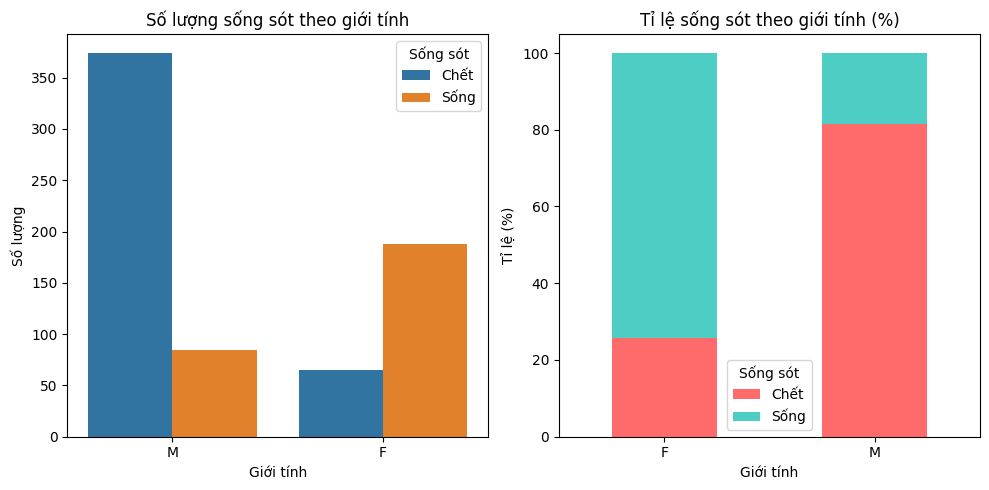


=== NHẬN XÉT ===
- Tỉ lệ nữ sống sót cao hơn nam rất nhiều
- Phụ nữ được ưu tiên lên xuồng cứu sinh
  Nữ: 74.3% sống sót
  Nam: 18.5% sống sót


In [20]:
#phần2
#câu12
# Trực quan tỉ lệ sống sót theo giới tính
plt.figure(figsize=(10, 5))

# Biểu đồ 1: Số lượng sống/chết theo giới tính
plt.subplot(1, 2, 1)
sns.countplot(data=train_df, x='Sex', hue='Survived')
plt.title('Số lượng sống sót theo giới tính')
plt.xlabel('Giới tính')
plt.ylabel('Số lượng')
plt.legend(title='Sống sót', labels=['Chết', 'Sống'])

# Biểu đồ 2: Tỉ lệ phần trăm
plt.subplot(1, 2, 2)
survived_by_sex = pd.crosstab(train_df['Sex'], train_df['Survived'], normalize='index') * 100
survived_by_sex.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#ff6b6b', '#4ecdc4'])
plt.title('Tỉ lệ sống sót theo giới tính (%)')
plt.xlabel('Giới tính')
plt.ylabel('Tỉ lệ (%)')
plt.legend(title='Sống sót', labels=['Chết', 'Sống'])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# Nhận xét
print("\n=== NHẬN XÉT ===")
print("- Tỉ lệ nữ sống sót cao hơn nam rất nhiều")
print("- Phụ nữ được ưu tiên lên xuồng cứu sinh")
survived_rate = train_df.groupby('Sex')['Survived'].mean() * 100
print(f"  Nữ: {survived_rate['F']:.1f}% sống sót")
print(f"  Nam: {survived_rate['M']:.1f}% sống sót")

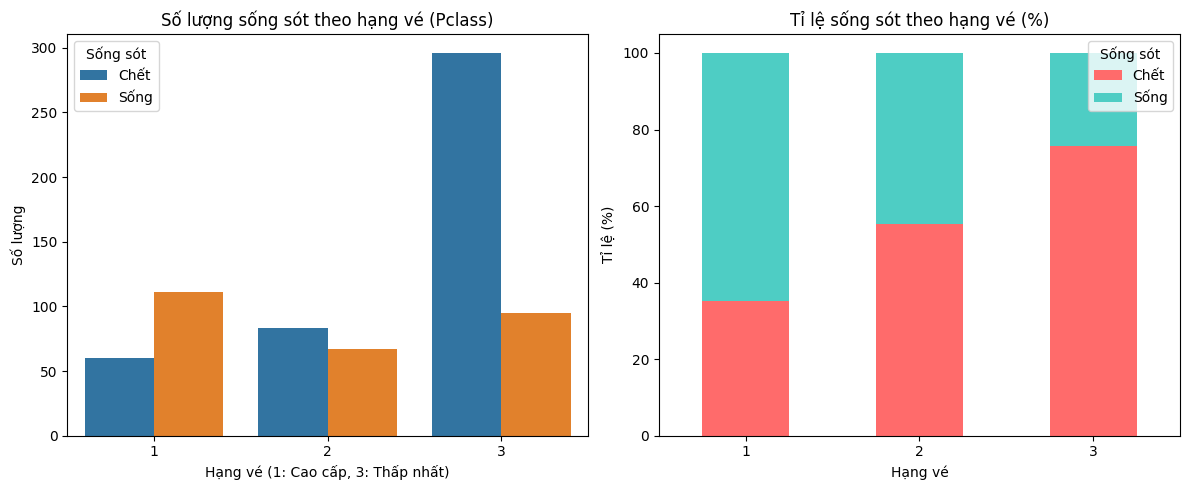


=== NHẬN XÉT ===
- Hạng 1: 64.9% sống sót
- Hạng 2: 44.7% sống sót
- Hạng 3: 24.3% sống sót
- Hành khách hạng cao cấp (1) có tỉ lệ sống sót cao nhất
- Nguyên nhân: Vị trí cabin gần xuồng cứu sinh, ưu tiên cứu hộ


In [21]:
#câu13
plt.figure(figsize=(12, 5))

# Biểu đồ 1: Số lượng sống/chết theo Pclass
plt.subplot(1, 2, 1)
sns.countplot(data=train_df, x='Pclass', hue='Survived')
plt.title('Số lượng sống sót theo hạng vé (Pclass)')
plt.xlabel('Hạng vé (1: Cao cấp, 3: Thấp nhất)')
plt.ylabel('Số lượng')
plt.legend(title='Sống sót', labels=['Chết', 'Sống'])

# Biểu đồ 2: Tỉ lệ phần trăm
plt.subplot(1, 2, 2)
survived_by_class = pd.crosstab(train_df['Pclass'], train_df['Survived'], normalize='index') * 100
survived_by_class.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#ff6b6b', '#4ecdc4'])
plt.title('Tỉ lệ sống sót theo hạng vé (%)')
plt.xlabel('Hạng vé')
plt.ylabel('Tỉ lệ (%)')
plt.legend(title='Sống sót', labels=['Chết', 'Sống'])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# Nhận xét
print("\n=== NHẬN XÉT ===")
survived_rate = train_df.groupby('Pclass')['Survived'].mean() * 100
print(f"- Hạng 1: {survived_rate[1]:.1f}% sống sót")
print(f"- Hạng 2: {survived_rate[2]:.1f}% sống sót")
print(f"- Hạng 3: {survived_rate[3]:.1f}% sống sót")
print("- Hành khách hạng cao cấp (1) có tỉ lệ sống sót cao nhất")
print("- Nguyên nhân: Vị trí cabin gần xuồng cứu sinh, ưu tiên cứu hộ")

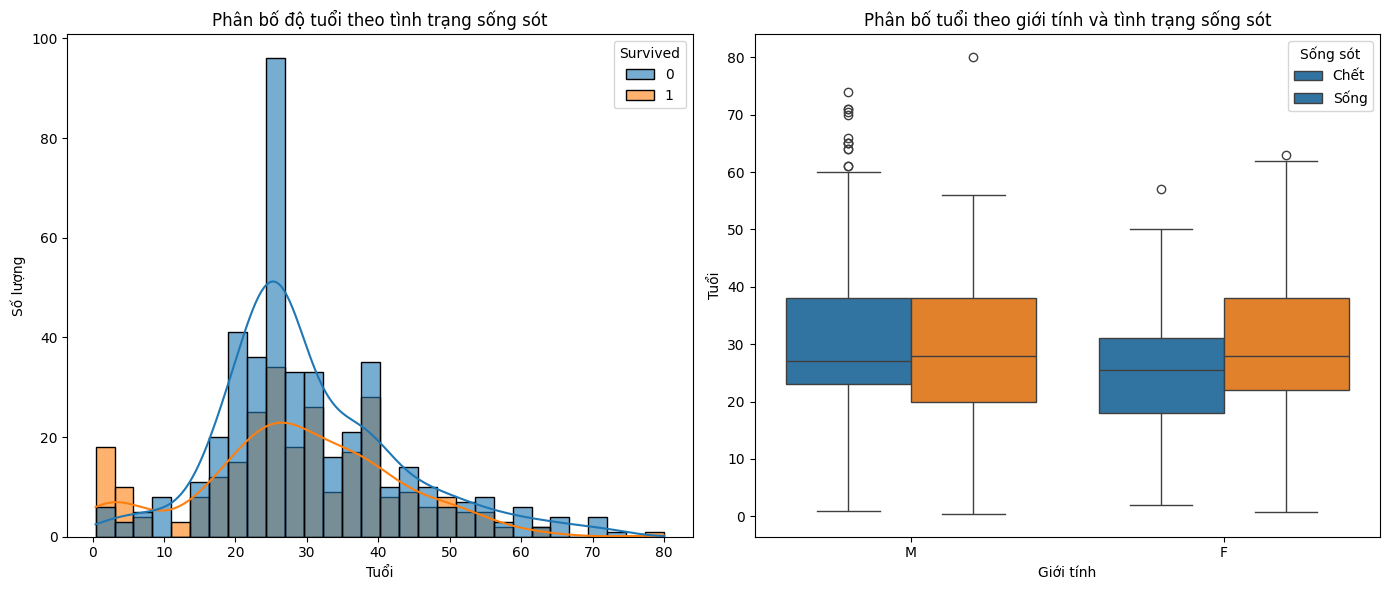

<Figure size 1000x600 with 0 Axes>

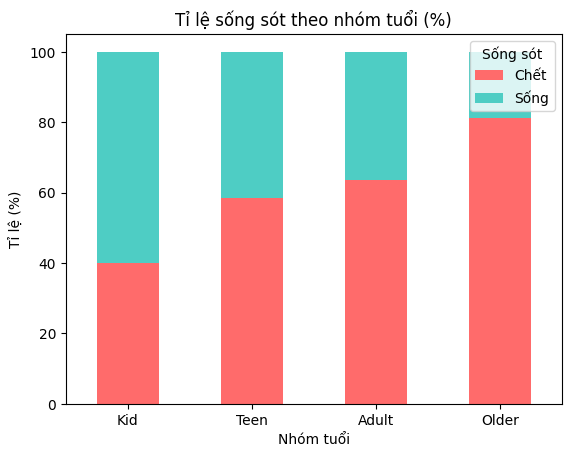


=== NHẬN XÉT ===
- Trẻ em (Kid) có tỉ lệ sống sót cao: 'Children and women first'
- Người già (Older) có tỉ lệ sống sót thấp hơn
- Nam giới trưởng thành (Adult male) có tỉ lệ tử vong cao nhất
- Phụ nữ trẻ có tỉ lệ sống cao hơn phụ nữ lớn tuổi


In [22]:
#câu14
plt.figure(figsize=(14, 6))

# Biểu đồ 1: Phân bố tuổi theo nhóm sống/chết
plt.subplot(1, 2, 1)
sns.histplot(data=train_df, x='Age', hue='Survived', kde=True, bins=30, alpha=0.6)
plt.title('Phân bố độ tuổi theo tình trạng sống sót')
plt.xlabel('Tuổi')
plt.ylabel('Số lượng')

# Biểu đồ 2: Boxplot theo giới tính và tình trạng sống
plt.subplot(1, 2, 2)
sns.boxplot(data=train_df, x='Sex', y='Age', hue='Survived')
plt.title('Phân bố tuổi theo giới tính và tình trạng sống sót')
plt.xlabel('Giới tính')
plt.ylabel('Tuổi')
plt.legend(title='Sống sót', labels=['Chết', 'Sống'])

plt.tight_layout()
plt.show()

# Biểu đồ phụ: Tỉ lệ sống theo nhóm tuổi (Agegroup đã tạo ở PHẦN 6)
plt.figure(figsize=(10, 6))
survived_by_agegroup = pd.crosstab(train_df['Agegroup'], train_df['Survived'], normalize='index') * 100
survived_by_agegroup.plot(kind='bar', stacked=True, color=['#ff6b6b', '#4ecdc4'])
plt.title('Tỉ lệ sống sót theo nhóm tuổi (%)')
plt.xlabel('Nhóm tuổi')
plt.ylabel('Tỉ lệ (%)')
plt.legend(title='Sống sót', labels=['Chết', 'Sống'])
plt.xticks(rotation=0)
plt.show()

# Nhận xét
print("\n=== NHẬN XÉT ===")
print("- Trẻ em (Kid) có tỉ lệ sống sót cao: 'Children and women first'")
print("- Người già (Older) có tỉ lệ sống sót thấp hơn")
print("- Nam giới trưởng thành (Adult male) có tỉ lệ tử vong cao nhất")
print("- Phụ nữ trẻ có tỉ lệ sống cao hơn phụ nữ lớn tuổi")

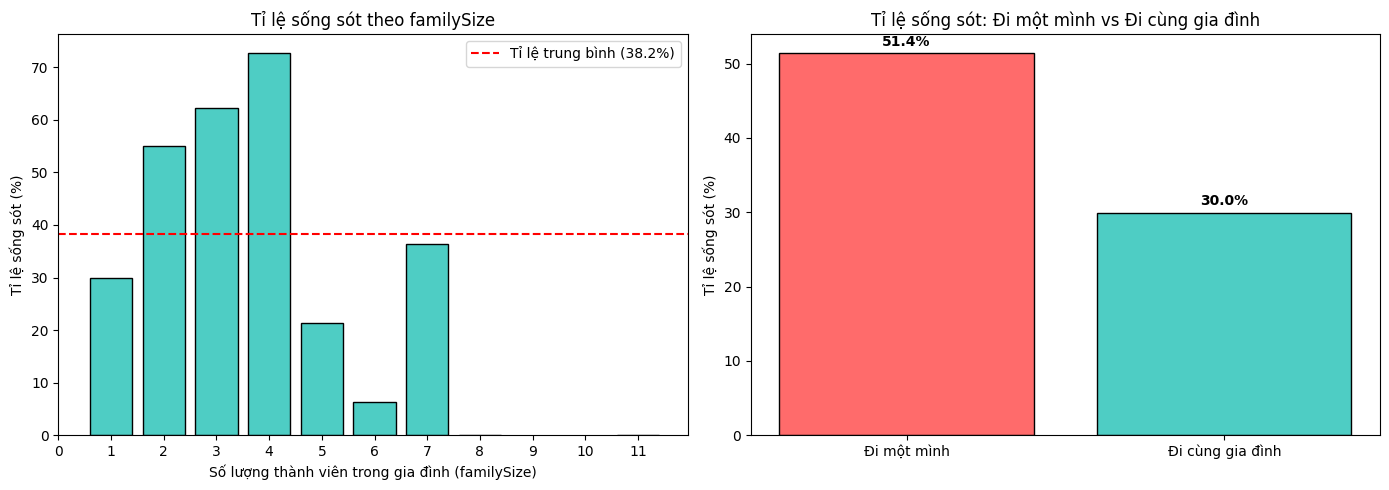


=== NHẬN XÉT ===
- familySize = 2-4 có tỉ lệ sống cao nhất
- Đi một mình (Alone=1) có tỉ lệ sống thấp hơn so với đi cùng gia đình
- Gia đình quá đông (familySize > 4) cũng khó sống sót
- Nguyên nhân: Hỗ trợ lẫn nhau, nhưng đông quá khó di chuyển


In [23]:
#câu15
plt.figure(figsize=(14, 5))

# Biểu đồ 1: Tỉ lệ sống theo familySize
plt.subplot(1, 2, 1)
family_survival = train_df.groupby('familySize')['Survived'].mean() * 100
plt.bar(family_survival.index, family_survival.values, color='#4ecdc4', edgecolor='black')
plt.title('Tỉ lệ sống sót theo familySize')
plt.xlabel('Số lượng thành viên trong gia đình (familySize)')
plt.ylabel('Tỉ lệ sống sót (%)')
plt.xticks(range(0, 12))
plt.axhline(y=38.2, color='red', linestyle='--', label='Tỉ lệ trung bình (38.2%)')
plt.legend()

# Biểu đồ 2: So sánh Alone vs có người đi cùng
plt.subplot(1, 2, 2)
alone_survival = train_df.groupby('Alone')['Survived'].mean() * 100
colors = ['#ff6b6b', '#4ecdc4']
plt.bar(['Đi một mình', 'Đi cùng gia đình'], alone_survival.values, color=colors, edgecolor='black')
plt.title('Tỉ lệ sống sót: Đi một mình vs Đi cùng gia đình')
plt.ylabel('Tỉ lệ sống sót (%)')
for i, v in enumerate(alone_survival.values):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Nhận xét
print("\n=== NHẬN XÉT ===")
print("- familySize = 2-4 có tỉ lệ sống cao nhất")
print("- Đi một mình (Alone=1) có tỉ lệ sống thấp hơn so với đi cùng gia đình")
print("- Gia đình quá đông (familySize > 4) cũng khó sống sót")
print("- Nguyên nhân: Hỗ trợ lẫn nhau, nhưng đông quá khó di chuyển")

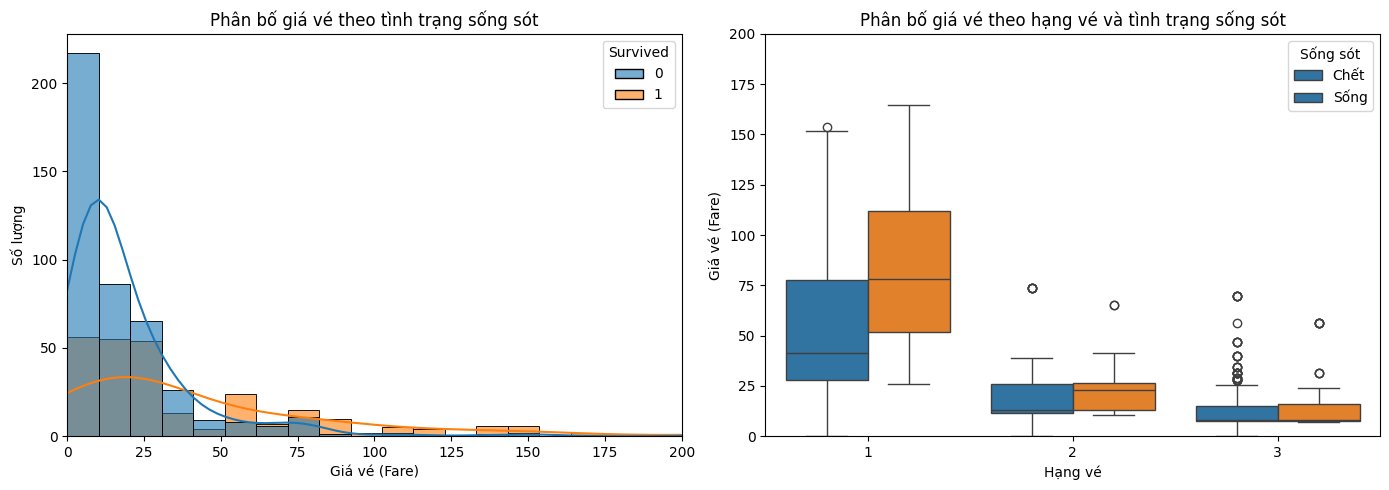

/tmp/ipykernel_4322/538592804.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fare_group_survival = train_df.groupby('FareGroup')['Survived'].mean() * 100


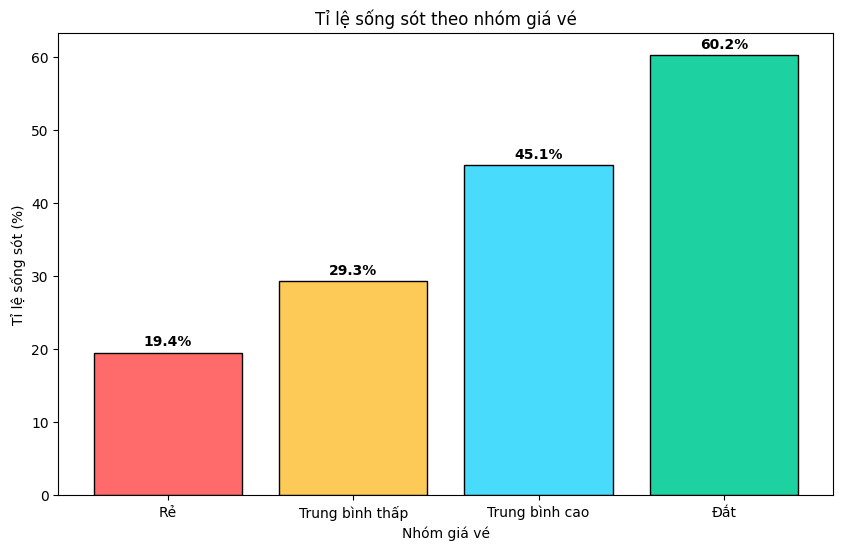


=== NHẬN XÉT ===
- Giá vé càng cao, tỉ lệ sống sót càng lớn
- Nhóm giá vé đắt nhất có tỉ lệ sống trên 50%
- Nhóm giá vé rẻ nhất có tỉ lệ sống dưới 20%
- Tương quan chặt chẽ với Pclass: hạng 1 vé đắt hơn và sống nhiều hơn


In [24]:
#câu16
plt.figure(figsize=(14, 5))

# Biểu đồ 1: Phân bố Fare theo tình trạng sống
plt.subplot(1, 2, 1)
sns.histplot(data=train_df, x='Fare', hue='Survived', kde=True, bins=50, alpha=0.6)
plt.title('Phân bố giá vé theo tình trạng sống sót')
plt.xlabel('Giá vé (Fare)')
plt.ylabel('Số lượng')
plt.xlim(0, 200)  # Giới hạn để nhìn rõ hơn

# Biểu đồ 2: Boxplot Fare theo Pclass và Survived
plt.subplot(1, 2, 2)
sns.boxplot(data=train_df, x='Pclass', y='Fare', hue='Survived')
plt.title('Phân bố giá vé theo hạng vé và tình trạng sống sót')
plt.xlabel('Hạng vé')
plt.ylabel('Giá vé (Fare)')
plt.legend(title='Sống sót', labels=['Chết', 'Sống'])
plt.ylim(0, 200)

plt.tight_layout()
plt.show()

# Biểu đồ phụ: Chia Fare thành các khoảng
plt.figure(figsize=(10, 6))
train_df['FareGroup'] = pd.qcut(train_df['Fare'], q=4, labels=['Rẻ', 'Trung bình thấp', 'Trung bình cao', 'Đắt'])
fare_group_survival = train_df.groupby('FareGroup')['Survived'].mean() * 100
colors = ['#ff6b6b', '#feca57', '#48dbfb', '#1dd1a1']
plt.bar(fare_group_survival.index, fare_group_survival.values, color=colors, edgecolor='black')
plt.title('Tỉ lệ sống sót theo nhóm giá vé')
plt.xlabel('Nhóm giá vé')
plt.ylabel('Tỉ lệ sống sót (%)')
for i, v in enumerate(fare_group_survival.values):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.show()

# Nhận xét
print("\n=== NHẬN XÉT ===")
print("- Giá vé càng cao, tỉ lệ sống sót càng lớn")
print("- Nhóm giá vé đắt nhất có tỉ lệ sống trên 50%")
print("- Nhóm giá vé rẻ nhất có tỉ lệ sống dưới 20%")
print("- Tương quan chặt chẽ với Pclass: hạng 1 vé đắt hơn và sống nhiều hơn")

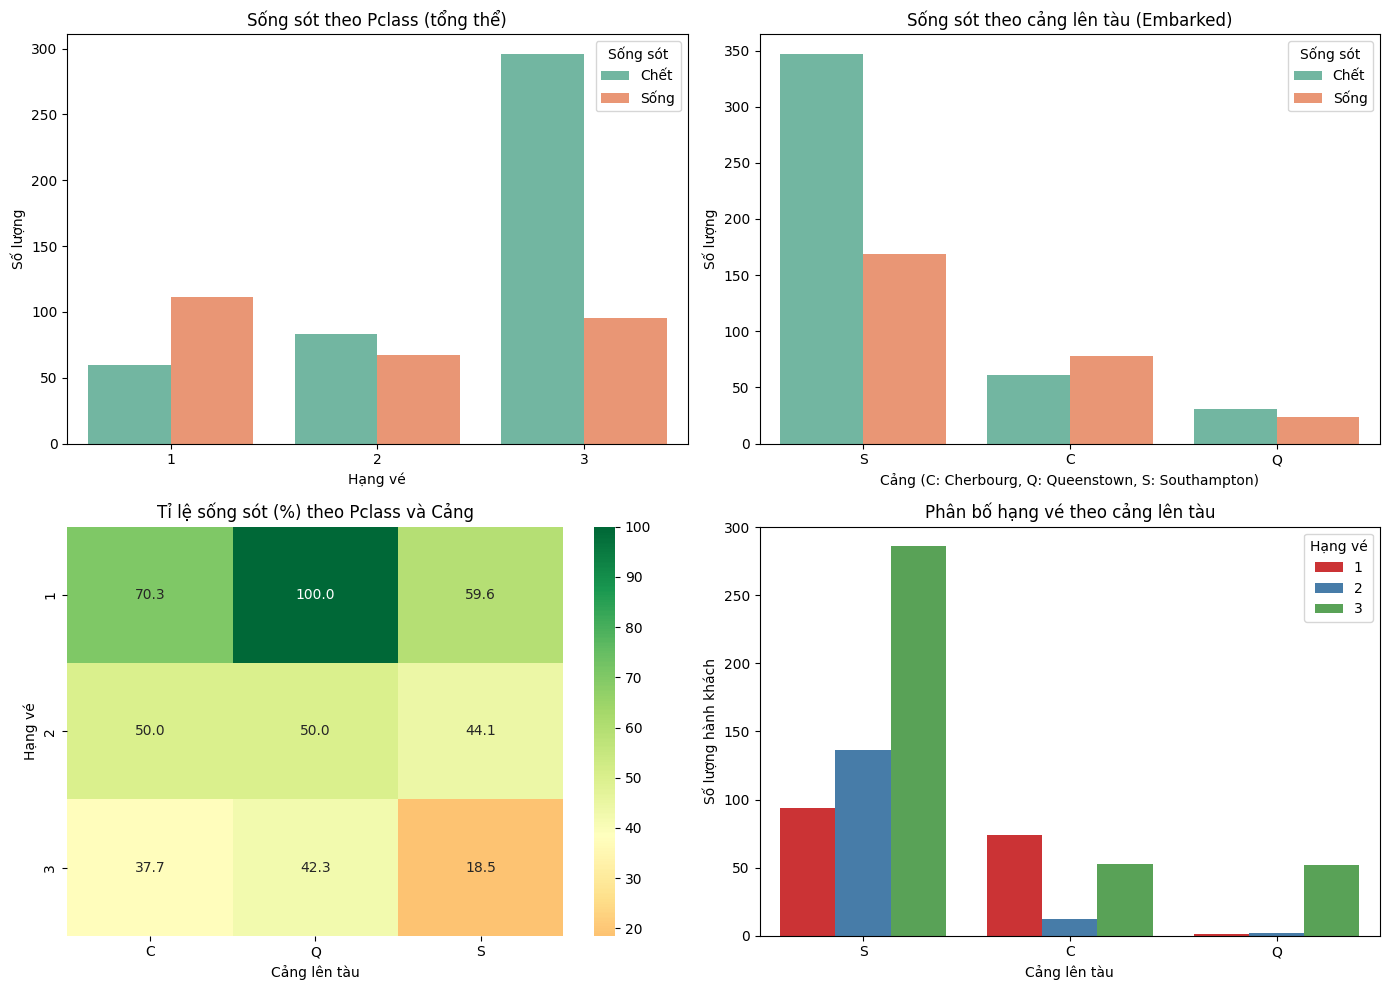


=== NHẬN XÉT ===
1. Theo cảng Embarked:
   - Cherbourg (C): 56.1% sống sót (cao nhất)
   - Queenstown (Q): 43.6% sống sót
   - Southampton (S): 32.8% sống sót (thấp nhất)

2. Giải thích:
   - Cảng C (Cherbourg): nhiều hành khách hạng 1, giàu có hơn
   - Cảng S (Southampton): nhiều hành khách hạng 3 nhất
   - Tỉ lệ sống phụ thuộc nhiều vào Pclass hơn là cảng


In [25]:
#câu 17
plt.figure(figsize=(14, 10))

# Biểu đồ 1: Số lượng sống/chết theo Pclass và Embarked
plt.subplot(2, 2, 1)
sns.countplot(data=train_df, x='Pclass', hue='Survived', palette='Set2')
plt.title('Sống sót theo Pclass (tổng thể)')
plt.xlabel('Hạng vé')
plt.ylabel('Số lượng')
plt.legend(title='Sống sót', labels=['Chết', 'Sống'])

# Biểu đồ 2: Số lượng sống/chết theo Embarked
plt.subplot(2, 2, 2)
sns.countplot(data=train_df, x='Embarked', hue='Survived', palette='Set2')
plt.title('Sống sót theo cảng lên tàu (Embarked)')
plt.xlabel('Cảng (C: Cherbourg, Q: Queenstown, S: Southampton)')
plt.ylabel('Số lượng')
plt.legend(title='Sống sót', labels=['Chết', 'Sống'])

# Biểu đồ 3: Tỉ lệ sống theo Pclass và Embarked (Heatmap)
plt.subplot(2, 2, 3)
pivot_table = pd.crosstab(train_df['Pclass'], train_df['Embarked'],
                          values=train_df['Survived'], aggfunc='mean') * 100
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='RdYlGn', center=38.2)
plt.title('Tỉ lệ sống sót (%) theo Pclass và Cảng')
plt.xlabel('Cảng lên tàu')
plt.ylabel('Hạng vé')

# Biểu đồ 4: Số lượng hành khách theo Pclass và Embarked
plt.subplot(2, 2, 4)
sns.countplot(data=train_df, x='Embarked', hue='Pclass', palette='Set1')
plt.title('Phân bố hạng vé theo cảng lên tàu')
plt.xlabel('Cảng lên tàu')
plt.ylabel('Số lượng hành khách')
plt.legend(title='Hạng vé')

plt.tight_layout()
plt.show()

# Nhận xét
print("\n=== NHẬN XÉT ===")
print("1. Theo cảng Embarked:")
embarked_survival = train_df.groupby('Embarked')['Survived'].mean() * 100
print(f"   - Cherbourg (C): {embarked_survival['C']:.1f}% sống sót (cao nhất)")
print(f"   - Queenstown (Q): {embarked_survival['Q']:.1f}% sống sót")
print(f"   - Southampton (S): {embarked_survival['S']:.1f}% sống sót (thấp nhất)")

print("\n2. Giải thích:")
print("   - Cảng C (Cherbourg): nhiều hành khách hạng 1, giàu có hơn")
print("   - Cảng S (Southampton): nhiều hành khách hạng 3 nhất")
print("   - Tỉ lệ sống phụ thuộc nhiều vào Pclass hơn là cảng")